In [49]:
# =====================================================
# Plant Disease Detection using Transfer Learning
# MobileNetV2
# =====================================================

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [50]:
# =====================================================
# Project Configuration
# =====================================================

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image Parameters
IMAGE_SIZE = (224, 224)
IMG_HEIGHT = IMAGE_SIZE[0]
IMG_WIDTH = IMAGE_SIZE[1]
CHANNELS = 3

# Training Parameters
BATCH_SIZE = 32
EPOCHS = 30

# Dataset Path
DATASET_PATH = r"D:\RishabhPant\JupyterNotebook\projects\Plant_Disease_Detection\dataset"

print("Configuration Loaded Successfully!")
print(f"Image Size : {IMAGE_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Epochs     : {EPOCHS}")

Configuration Loaded Successfully!
Image Size : (224, 224)
Batch Size : 32
Epochs     : 30


In [51]:
# =====================================================
# Load Dataset
# =====================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Store class names
class_names = train_ds.class_names
display_names = {
    "healthy": "Healthy",
    "leaf_blight": "Leaf Blight",
    "yellow_mottle_virus": "Yellow Mottle Virus"
}
num_classes = len(class_names)

print("\nClass Names:")
print(class_names)

print(f"\nTotal Classes : {num_classes}")

Found 819 files belonging to 3 classes.
Using 656 files for training.
Found 819 files belonging to 3 classes.
Using 163 files for validation.

Class Names:
['healthy', 'leaf_blight', 'yellow_mottle_virus']

Total Classes : 3


In [52]:
# =====================================================
# Optimize Dataset Performance
# =====================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset Optimized Successfully!")


Dataset Optimized Successfully!


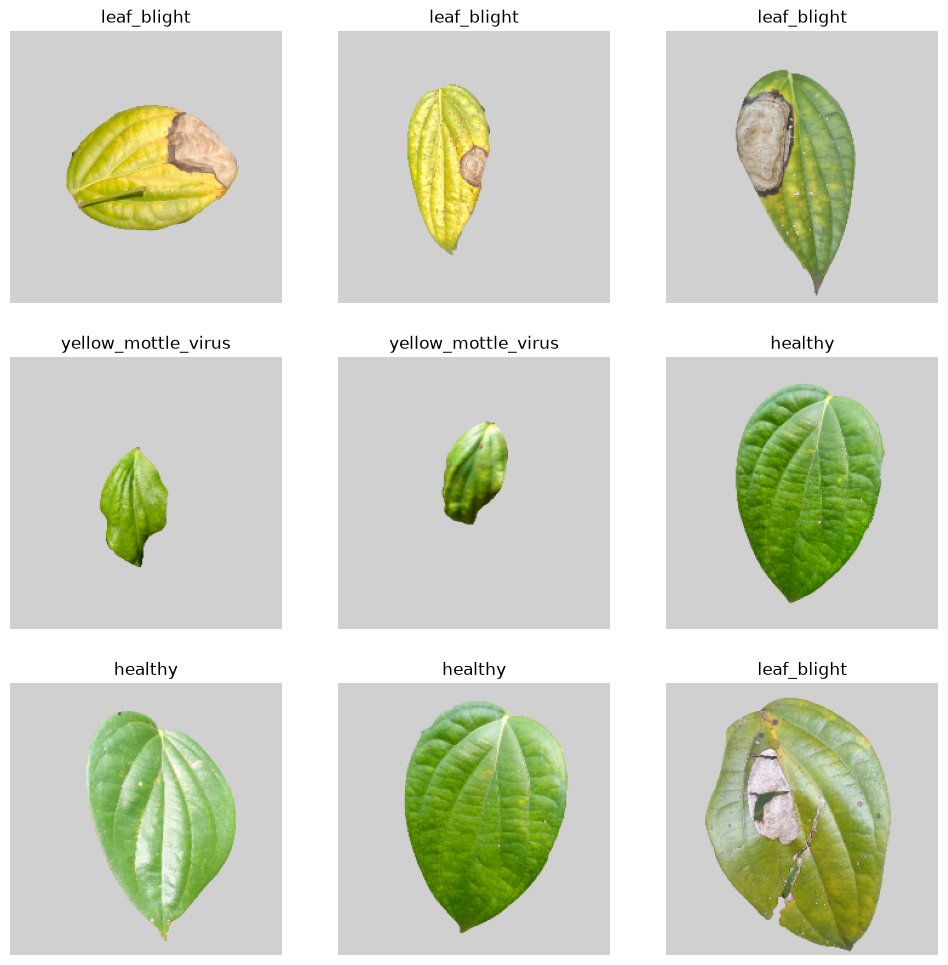

In [53]:
# =====================================================
# Visualize Dataset
# =====================================================

plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [55]:
# =====================================================
# Save Class Names
# =====================================================

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved successfully!")

class_names.json saved successfully!


In [56]:
# =====================================================
# Data Augmentation
# =====================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

print("Data Augmentation Ready!")

Data Augmentation Ready!


In [57]:
# =====================================================
# Build MobileNetV2 Model
# =====================================================

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = preprocess_input(x)

# Feature extraction
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.20)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [58]:
# =====================================================
# Compile Model
# =====================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

# =====================================================
# Callbacks
# =====================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="plant_disease_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr,
    checkpoint
]

print("Callbacks Ready!")

Model Compiled Successfully!
Callbacks Ready!


In [59]:
# =====================================================
# Train Model
# =====================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining Completed Successfully!")

Epoch 1/30


c:\Users\rishi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.7805 - loss: 0.5181
Epoch 1: val_accuracy improved from None to 0.98160, saving model to plant_disease_model.keras

Epoch 1: finished saving model to plant_disease_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 822ms/step - accuracy: 0.7805 - loss: 0.5181 - val_accuracy: 0.9816 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9421 - loss: 0.1656
Epoch 2: val_accuracy did not improve from 0.98160
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 711ms/step - accuracy: 0.9421 - loss: 0.1656 - val_accuracy: 0.9816 - val_loss: 0.0672 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.9604 - loss: 0.1072
Epoch 3: val_accuracy did not improve from 0.98160
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 734ms/step - accuracy: 0.9604 - loss: 0.1072 - val_accuracy: 0.9816 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.981

In [67]:
# =====================================================
# Load Best Model
# =====================================================

model = tf.keras.models.load_model("plant_disease_model.keras")

print("Plant Diesease Model Loaded Successfully!")

Plant Diesease Model Loaded Successfully!


In [68]:
# =====================================================
# Save Class Names
# =====================================================

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class Names Saved Successfully!")

Class Names Saved Successfully!


In [69]:
# =====================================================
# Evaluate Model
# =====================================================

loss, accuracy = model.evaluate(val_ds, verbose=1)

print("\n==============================")
print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")
print("==============================")

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 449ms/step - accuracy: 0.9816 - loss: 0.0887

Validation Loss     : 0.0887
Validation Accuracy : 98.16%


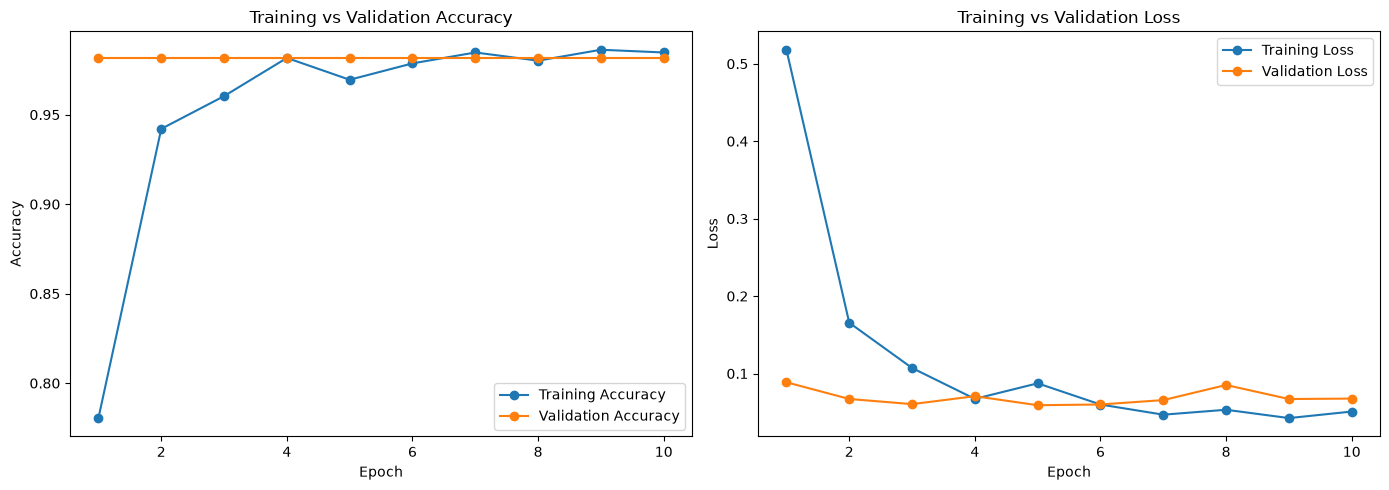

In [70]:
# =====================================================
# Plot Training History
# =====================================================

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(epochs_range, acc, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="o", label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

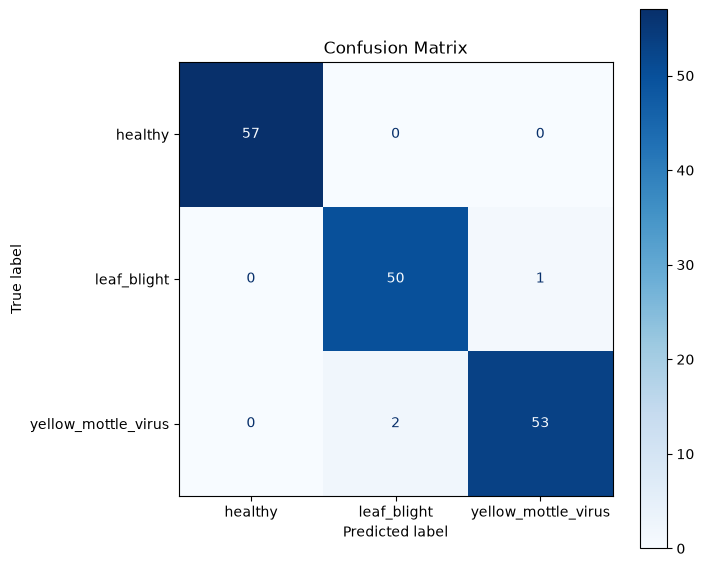

In [71]:
# =====================================================
# Confusion Matrix
# =====================================================

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Confusion Matrix")

plt.show()

In [72]:
# =====================================================
# Classification Report
# =====================================================

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                     precision    recall  f1-score   support

            healthy       1.00      1.00      1.00        57
        leaf_blight       0.96      0.98      0.97        51
yellow_mottle_virus       0.98      0.96      0.97        55

           accuracy                           0.98       163
          macro avg       0.98      0.98      0.98       163
       weighted avg       0.98      0.98      0.98       163



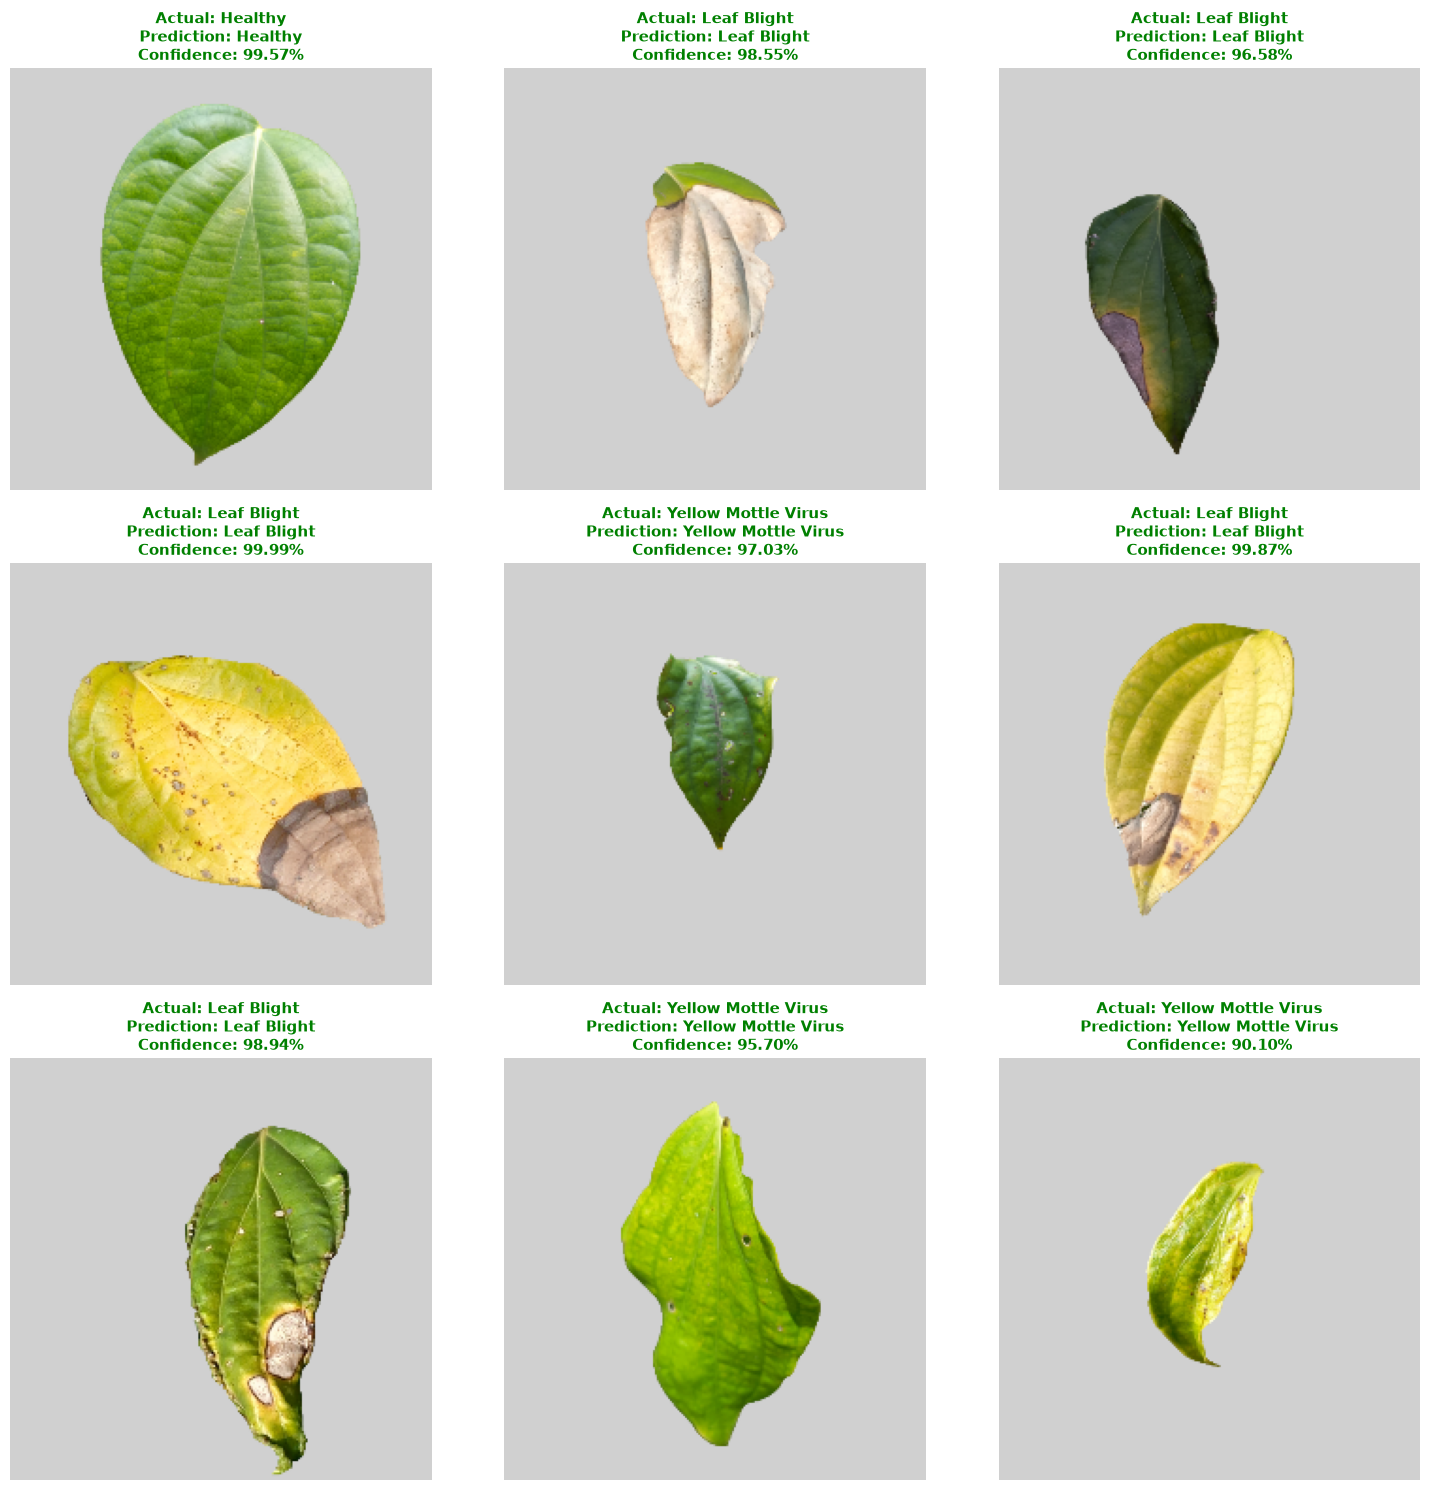

In [73]:
# =====================================================
# Predict Random Validation Images
# =====================================================

import random

plt.figure(figsize=(15, 15))

# Get one batch from validation dataset
images, labels = next(iter(val_ds))

# Select 9 random images
indices = random.sample(range(len(images)), 9)

for i, idx in enumerate(indices):

    image = images[idx]
    true_label = class_names[labels[idx]]

    # Prediction
    prediction = model.predict(
        tf.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_index = np.argmax(prediction)

    predicted_label = class_names[predicted_index]

    confidence = np.max(prediction) * 100

    # Plot image
    plt.subplot(3, 3, i + 1)

    plt.imshow(image.numpy().astype("uint8"))

    if predicted_label == true_label:
        color = "green"
    else:
        color = "red"

    plt.title(
        f"Actual: {display_names[true_label]}\n"
        f"Prediction: {display_names[predicted_label]}\n"
        f"Confidence: {confidence:.2f}%",
        color=color,
        fontsize=11,
        fontweight="bold"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [75]:
from PIL import Image
import numpy as np

# Load test image
img = Image.open(r"D:\RishabhPant\JupyterNotebook\projects\Plant_Disease_Detection\dataset\leaf_blight\LB0015.jpg").convert("RGB")
img = img.resize((224, 224))

# Prepare array for model (Note: MobileNetV2 normalization is already embedded inside plant_disease_model.keras)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

print("Prediction Vector:", prediction)
print("Predicted Class:", class_names[np.argmax(prediction)])


Prediction Vector: [[8.4466292e-03 9.9074626e-01 8.0715300e-04]]
Predicted Class: leaf_blight
